<a href="https://colab.research.google.com/github/Santosh-87/IMDB_Movie_Sentiment_Analysis/blob/main/IMDB_Movie_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# The file to be loaded from the kaggle data source
file_path = "IMDB Dataset.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
  file_path,
)


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
df.groupby(['sentiment'])[['sentiment']].count()

,sentiment
sentiment,
negative,25000
positive,25000


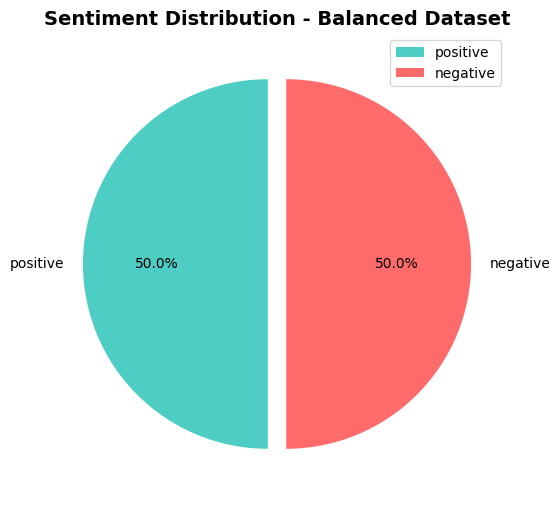

In [9]:
plt.figure(figsize=(8, 6))
sentiment_counts = df['sentiment'].value_counts()
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=['#4ecdc4', '#ff6b6b'], startangle=90, explode=[0.05, 0.05])
plt.title('Sentiment Distribution - Balanced Dataset', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.show()

In [10]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [11]:
df['review_length'] = df['review'].apply(len)

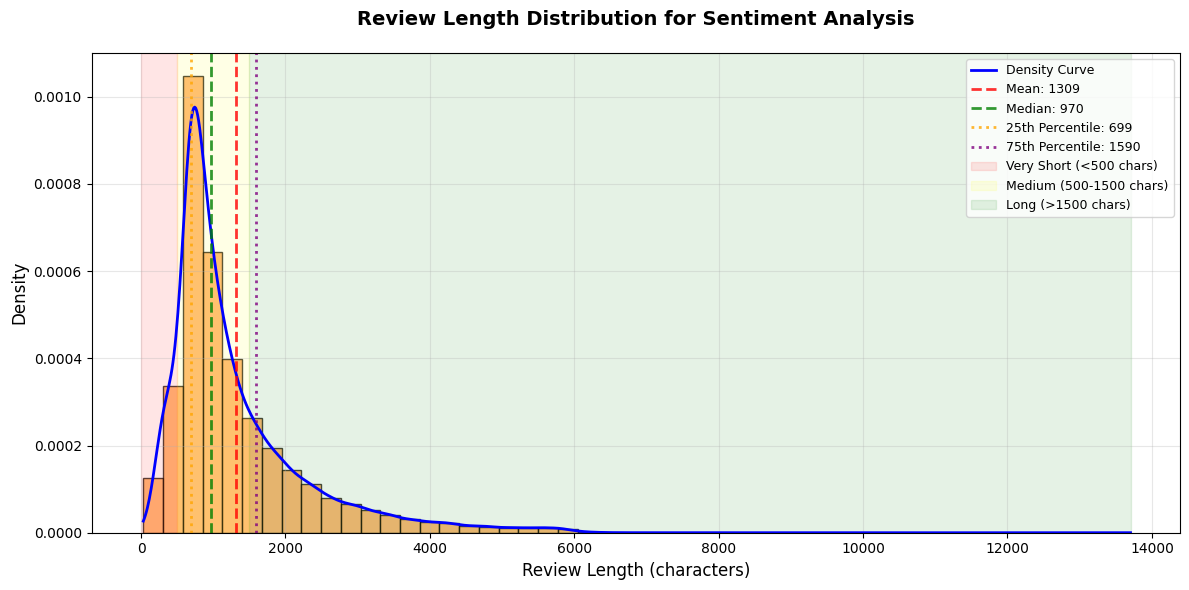

In [12]:
plt.figure(figsize=(12, 6))

# Create histogram with density curve
plt.hist(df['review_length'], bins=50,
         color='#ff9f43', edgecolor='black',
         alpha=0.7, density=True)

# Add kernel density estimate (smooth curve)
from scipy import stats
kde = stats.gaussian_kde(df['review_length'])
x_range = np.linspace(df['review_length'].min(), df['review_length'].max(), 1000)
plt.plot(x_range, kde(x_range), 'b-', linewidth=2, label='Density Curve')

# Add statistical lines (LEGEND ONLY - no text box)
stats_lines = [
    ('Mean', df['review_length'].mean(), 'red', '--'),
    ('Median', df['review_length'].median(), 'green', '--'),
    ('25th Percentile', df['review_length'].quantile(0.25), 'orange', ':'),
    ('75th Percentile', df['review_length'].quantile(0.75), 'purple', ':')
]

for name, value, color, style in stats_lines:
    plt.axvline(value, color=color, linestyle=style, linewidth=2,
                alpha=0.8, label=f'{name}: {value:.0f}')

# Highlight different regions
plt.axvspan(0, 500, alpha=0.1, color='red', label='Very Short (<500 chars)')
plt.axvspan(500, 1500, alpha=0.1, color='yellow', label='Medium (500-1500 chars)')
plt.axvspan(1500, df['review_length'].max(), alpha=0.1, color='green',
            label='Long (>1500 chars)')

# Labels and formatting
plt.xlabel('Review Length (characters)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Review Length Distribution for Sentiment Analysis',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
def no_of_words(text):
  words = text.split()
  word_count = len(words)
  return word_count

In [14]:
df['word_count'] = df['review'].apply(no_of_words)

In [15]:
df.head(10)

,review,sentiment,review_length,word_count
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230
5,"Probably my all-time favorite movie, a story o...",positive,656,119
6,I sure would like to see a resurrection of a u...,positive,726,150
7,"This show was an amazing, fresh & innovative i...",negative,934,174
8,Encouraged by the positive comments about this...,negative,681,130
9,If you like original gut wrenching laughter yo...,positive,176,33


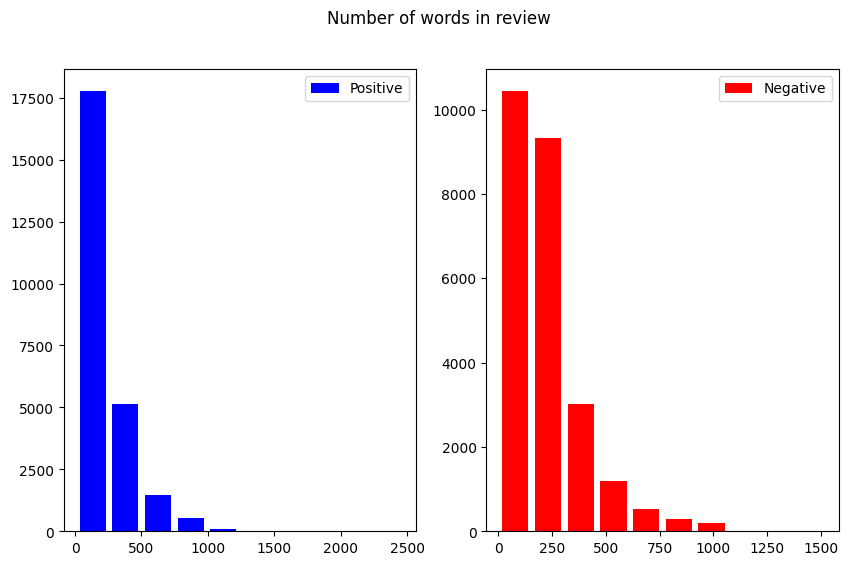

In [16]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['word_count'], label='Positive', color='blue', rwidth=0.8);
ax[1].hist(df[df['sentiment'] == 'negative']['word_count'], label='Negative', color='red', rwidth=0.8);

ax[0].legend(loc='upper right');
ax[1].legend(loc='upper right');

fig.suptitle("Number of words in review")
plt.show()

In [17]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [18]:
df.head()

,review,sentiment,review_length,word_count
0,One of the other reviewers has mentioned that ...,1,1761,307
1,A wonderful little production. <br /><br />The...,1,998,162
2,I thought this was a wonderful way to spend ti...,1,926,166
3,Basically there's a family where a little boy ...,0,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230


In [19]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
import re


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [20]:
stop_words = set(stopwords.words('english'))
lemm = WordNetLemmatizer()

def clean_text(review):

    review = BeautifulSoup(review, "html.parser").get_text()
    review = review.lower()
    review = re.sub(r"http\S+|www\S+|https\S+", "", review)
    review = re.sub(r"@\w+|#", "", review)
    review = re.sub("[^a-zA-Z]", " ", review)

    tokens = word_tokenize(review)

    filtered = [lemm.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(filtered)

In [21]:
df['clean_review'] = df['review'].apply(clean_text)

In [22]:
df['clean_review'][0]

'one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never far away would say main appeal show due fact go show dare forget pretty picture painted mainstream audience forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard sold nickel inmate kill order get away well mannered middle class inmate turned prison bitch due lack street skill prison experience watching oz m

In [23]:
df.sample(5)

,review,sentiment,review_length,word_count,clean_review
13081,"Hey now, I can't claim to have seen all of the...",1,1308,259,hey claim seen film jesse jesus franco sure se...
25661,It has very bad acting. Bad story lines. Bad c...,0,661,130,bad acting bad story line bad character never ...
9601,"This is a bizarre oddity, directed by the guy ...",1,500,87,bizarre oddity directed guy edited texas chain...
19351,This is quite possibly the most retarded 80's ...,0,2259,377,quite possibly retarded slasher ever realized ...
44462,Director Kinka Usher stays true to his own cre...,1,3339,563,director kinka usher stay true credo play stra...


In [24]:
!python -m nltk.downloader punkt punkt_tab stopwords wordnet
import nltk
nltk.data.path.append('/usr/share/nltk_data')

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [25]:
print(df.clean_review)

0        one reviewer mentioned watching oz episode hoo...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically family little boy jake think zombie ...
4        petter mattei love time money visually stunnin...
                               ...                        
49995    thought movie right good job creative original...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    going disagree previous comment side maltin on...
49999    one expects star trek movie high art fan expec...
Name: clean_review, Length: 50000, dtype: object


In [26]:
df['new_word_count'] = df['clean_review'].apply(no_of_words)
df.head()

,review,sentiment,review_length,word_count,clean_review,new_word_count
0,One of the other reviewers has mentioned that ...,1,1761,307,one reviewer mentioned watching oz episode hoo...,162
1,A wonderful little production. <br /><br />The...,1,998,162,wonderful little production filming technique ...,86
2,I thought this was a wonderful way to spend ti...,1,926,166,thought wonderful way spend time hot summer we...,84
3,Basically there's a family where a little boy ...,0,748,138,basically family little boy jake think zombie ...,64
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230,petter mattei love time money visually stunnin...,125


In [27]:
pos_reviews =  df[df.sentiment == 1]
pos_reviews.head()

,review,sentiment,review_length,word_count,clean_review,new_word_count
0,One of the other reviewers has mentioned that ...,1,1761,307,one reviewer mentioned watching oz episode hoo...,162
1,A wonderful little production. <br /><br />The...,1,998,162,wonderful little production filming technique ...,86
2,I thought this was a wonderful way to spend ti...,1,926,166,thought wonderful way spend time hot summer we...,84
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230,petter mattei love time money visually stunnin...,125
5,"Probably my all-time favorite movie, a story o...",1,656,119,probably time favorite movie story selflessnes...,54


In [28]:
neg_reviews =  df[df.sentiment == 0]
neg_reviews.head()

,review,sentiment,review_length,word_count,clean_review,new_word_count
3,Basically there's a family where a little boy ...,0,748,138,basically family little boy jake think zombie ...,64
7,"This show was an amazing, fresh & innovative i...",0,934,174,show amazing fresh innovative idea first aired...,78
8,Encouraged by the positive comments about this...,0,681,130,encouraged positive comment film looking forwa...,62
10,Phil the Alien is one of those quirky films wh...,0,578,96,phil alien one quirky film humour based around...,50
11,I saw this movie when I was about 12 when it c...,0,937,180,saw movie came recall scariest scene big bird ...,82


In [29]:
from collections import Counter
count = Counter()
for text in pos_reviews['clean_review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(20)

[('film', 49690),
 ('movie', 44835),
 ('one', 28280),
 ('like', 18193),
 ('time', 16309),
 ('good', 15089),
 ('story', 14181),
 ('character', 14020),
 ('great', 13009),
 ('see', 12926),
 ('well', 12827),
 ('make', 11242),
 ('get', 11194),
 ('also', 10792),
 ('really', 10736),
 ('would', 10594),
 ('scene', 10054),
 ('life', 9897),
 ('show', 9664),
 ('even', 9613)]

In [30]:
pos_words = pd.DataFrame(count.most_common(20))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,49690
1,movie,44835
2,one,28280
3,like,18193
4,time,16309


In [31]:
import plotly.express as px

In [32]:
px.bar(pos_words, x='count', y='word', title='Common words in positive reviews', color = 'word')

In [33]:
count = Counter()
for text in neg_reviews['clean_review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(20)

[('movie', 58403),
 ('film', 43733),
 ('one', 27152),
 ('like', 22927),
 ('even', 15244),
 ('time', 15146),
 ('good', 14763),
 ('bad', 14713),
 ('character', 14324),
 ('would', 14005),
 ('get', 13456),
 ('make', 12957),
 ('really', 12354),
 ('scene', 11378),
 ('see', 11138),
 ('story', 11082),
 ('much', 10115),
 ('people', 9536),
 ('thing', 9470),
 ('could', 9300)]

In [34]:
neg_words = pd.DataFrame(count.most_common(20))
neg_words.columns = ['word', 'count']
neg_words.head()

,word,count
0,movie,58403
1,film,43733
2,one,27152
3,like,22927
4,even,15244


In [35]:
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color = 'word')

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [37]:
def generate_word_cloud(text, title="Word Cloud"):
    """
    Generate and display a word cloud
    """
    # Create word cloud
    wordcloud = WordCloud(
        width=1500,
        height=1000,
        max_words=150,
        random_state=42,
        collocations=False,
        background_color="white"
    ).generate(text)

    # Display
    plt.figure(figsize=(14, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {title}", fontsize=30, pad=20)
    plt.show()

In [38]:
# Join all positive reviews
positive_text = " ".join(pos_reviews['clean_review'].values)

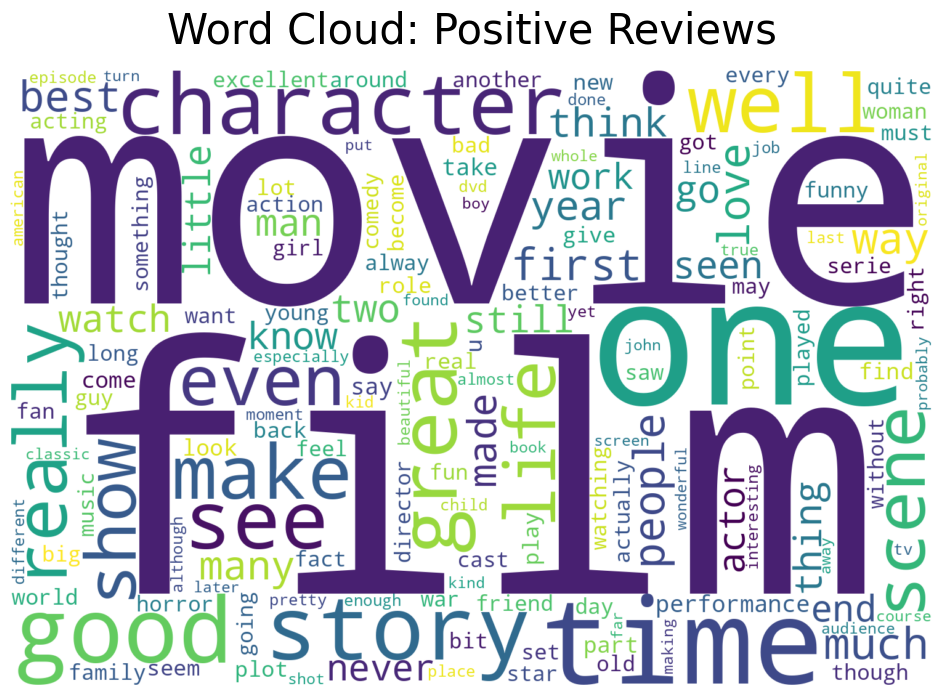

In [39]:
# Generate and display positive reviews word cloud
generate_word_cloud(positive_text, "Positive Reviews")

In [40]:
# Join all negative reviews
negative_text = " ".join(neg_reviews['clean_review'].values)

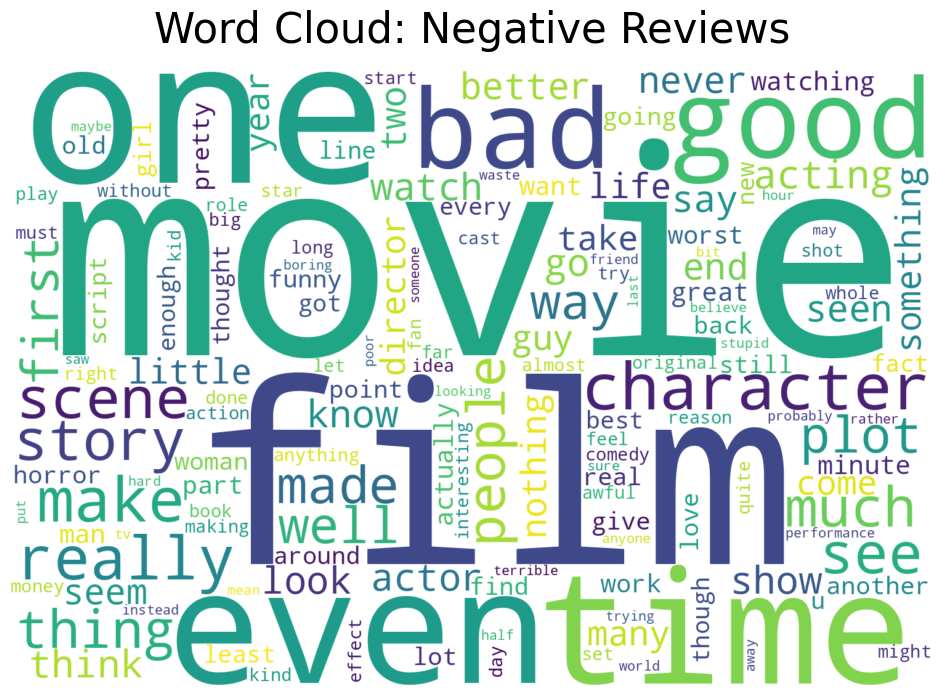

In [41]:
# Generate and display negative reviews word cloud
generate_word_cloud(negative_text, "Negative Reviews")

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [43]:
tfidf = TfidfVectorizer()

In [44]:
X = tfidf.fit_transform(df["clean_review"])
Y = df['sentiment']

In [45]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4731486 stored elements and shape (50000, 91606)>

In [46]:
Y

,sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((40000, 91606), (10000, 91606))

In [48]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()